---
title: "Building a Heterogeneous AI-Ready Data Cube with DEFAIR"
subtitle: "Four EUMETSAT sources, four geometries, one aligned cube : MSG SEVIRI × Metop EDLST × MTG GII × Metop IASI."
author: "Author: Alejandro Fonseca (EUMETSAT/Starion)"
tags: [DEFAIR, MSG, SEVIRI, Metop, EDLST, MTG, GII, IASI, data cube]
thumbnail: ../img/EUMETSAT-icon.png
license: MIT
copyright: "© 2026 EUMETSAT"
---

<div style="margin: 6px 0;">
  <a href="https://jupyter.central.data.destination-earth.eu/user-redirect/lab/tree/DestinE-DataLake-Lab/DEFAIR/DEDL_DEFAIR_Building_heterogeneous_data_cube_using_defair.ipynb" target="_blank" style="text-decoration: none;">
    <span class="launch">🚀 Launch in JupyterHub</span>
  </a>
</div>

### Contents

This notebook builds one analysis-ready data cube over Central and Western Europe for the first ten days of June 2026, from **four EUMETSAT sources that share nothing but the region they observe**. Each arrives in its own file format, on its own grid, from its own instrument, and DEFAIR reads, reprojects, time-aligns and merges all four into a single cube on one pinned grid, ready to be handed to any downstream model or analysis. 

### The four sources and why they are interesting together

The four were chosen precisely because their geometries are as different as EUMETSAT products get. **MSG SEVIRI** is a geostationary imager: it sees the whole disc at once from 36000 km up, on its own satellite projection, and delivers two thermal window channels used here. **Metop EDLST** is a land surface temperature product on a global sinusoidal grid of 18001 × 36000 pixels, from the AVHRR instrument on a polar orbiter, clear-sky only. **MTG GII** is the Global Instability Index, a Level 2 product on the geostationary MTG grid giving atmospheric stability indices, retrieved only where the sky is clear. **Metop IASI** is an infrared sounder: it does not an image, it scans in a narrow swath along the orbit track, and returns retrieved profiles and a surface temperature, one narrow strip per overpass, so a single day leaves gaps between passes.

Two imagers, two very different data types, a global sinusoidal field and an orbital swath, each stored in its own native geometry. A model needs the opposite: a single table where each row represents a location and contains all relevant variables. Converting these four native geometries into that unified table is the core task, `and DEFAIR does it in a single alignment call`.

### What DEFAIR is used for

`Dataset.from_source` opens each source with the reader named for its format, `msg15nat`, `metop_edlst`, `mtg_l2_gii`, `metop_iasisnd02`, streaming the raw files straight from one S3 bucket. `content_filter` and read-time channel selection keep only the variables of interest. `spatial_filter` crops the base source to the exact study area and pre-crops the global sources to the study area plus a margin, so the alignment never inflates a full-globe field. The `AlignmentPlugin` reprojects the four native geometries onto one pinned `ReferenceGrid`, including the **swath resampling** that maps IASI's orbital strips onto the regular grid, aligns the daily time axes, and merges everything into one cube. `temporal_aggregate` collapses the ten daily fields into one summary field per variable. Every operation is recorded in the cube's CF history.

### Data sources

Study period: 1 to 10 June 2026. Area of interest: Central and Western Europe, latitude 36 to 54° N, longitude −10 to 15° E. All four sources live in one S3 bucket, streamed at read time; nothing is downloaded to local disk.

| Source | Instrument / platform | Native geometry | Variables taken | Format |
|---|---|---|---|---|
| MSG SEVIRI L1.5 | SEVIRI, geostationary | satellite projection, full disc | IR 10.8 µm, IR 12.0 µm brightness temperature | .nat |
| Metop EDLST | AVHRR, polar (LSA SAF) | global sinusoidal, 18001 × 36000 | land surface temperature (clear sky) | HDF5 |
| MTG GII | FCI, geostationary | MTG geostationary grid | K-index, lifted index, total precipitable water | netCDF |
| Metop IASI L2 | IASI sounder, polar | orbital swath, 120 across-track | retrieved surface temperature | native EPS |

Data © EUMETSAT and the LSA SAF, distributed through the Destination Earth Data Lake.

## Setup & Imports

In [1]:
%pip install --user --quiet cartopy aws-requests-auth

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from getpass import getpass

import boto3
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from affine import Affine

from defair.logging import setup_logging
from defair_data.core import Dataset
from defair_ops.transformations.alignment import AlignmentPlugin
from defair_ops.transformations.reprojection import ReferenceGrid

setup_logging(log_level="WARNING")  # "INFO", "WARNING", "ERROR"

### Configuration

Study area, study period, and the S3 bucket that holds all four raw sources under sibling prefixes. Credentials are entered at runtime and never stored in the notebook.

In [3]:
# Study area: Central & Western Europe
LAT_MIN, LAT_MAX = 36.0, 54.0
LON_MIN, LON_MAX = -10.0, 15.0
MARGIN = 2.0  # degrees, kept around the global sources so edge pixels retain their neighbours

# Study period: first ten days of June 2026
YEAR, MONTH = "2026", "06"
days = [f"{d:02d}" for d in range(1, 11)]

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

# ================================================================================
# S3 object store: one bucket, one set of credentials, four sibling prefixes
S3_ENDPOINT = "https://s3.central.data.destination-earth.eu"
BUCKET = "defair-use-case"
PREFIXES = {"msg": "msg-eu-orig/", "edlst": "edlst-eu-orig/",
            "gii": "gii-eu-orig/", "iasi": "iasi-eu-orig/"}
# ================================================================================

S3_ACCESS_KEY = getpass("S3 access key: ")
S3_SECRET_KEY = getpass("S3 secret key: ")

s3 = boto3.session.Session(
    aws_access_key_id=S3_ACCESS_KEY,
    aws_secret_access_key=S3_SECRET_KEY,
).client("s3", endpoint_url=S3_ENDPOINT)   # endpoint_url is required, otherwise boto3 targets AWS

S3_SOURCE_KWARGS = {
    "aws_access_key_id": S3_ACCESS_KEY,
    "aws_secret_access_key": S3_SECRET_KEY,
    "endpoint_url": S3_ENDPOINT,
}

paginator = s3.get_paginator("list_objects_v2")
def s3_keys(prefix):
    """All object keys under a prefix, paginated (the S3 API pages at 1000 keys)."""
    return sorted(o["Key"] for p in paginator.paginate(Bucket=BUCKET, Prefix=prefix)
                  for o in p.get("Contents", []))

for name, prefix in PREFIXES.items():
    print(f"{name:6s} {prefix:16s} {len(s3_keys(prefix))} objects")

S3 access key:  ········
S3 secret key:  ········


msg    msg-eu-orig/     30 objects
edlst  edlst-eu-orig/   30 objects
gii    gii-eu-orig/     80 objects
iasi   iasi-eu-orig/    32 objects


### The common target grid, pinned as a ReferenceGrid

All four sources will land on one common grid: EPSG:4326 at 0.05° resolution (about 5.5 km), covering the study area. The grid is declared **explicitly** as a `ReferenceGrid`, fixing its CRS, pixel size, corner and dimensions in advance. This makes every run pixel-identical and deterministic, and lets DEFAIR skip the step where it would otherwise probe each input to work out an output geometry.

In [4]:
TARGET_RESOLUTION = 0.05  # degrees (~5.5 km)
grid_width = round((LON_MAX - LON_MIN) / TARGET_RESOLUTION)   # -> 500
grid_height = round((LAT_MAX - LAT_MIN) / TARGET_RESOLUTION)  # -> 360

project_grid = ReferenceGrid(
    crs="EPSG:4326",
    transform=Affine(TARGET_RESOLUTION, 0.0, LON_MIN, 0.0, -TARGET_RESOLUTION, LAT_MAX),
    width=grid_width,
    height=grid_height,
)
print(f"Reference grid: {project_grid.crs} | {grid_width} x {grid_height} pixels @ {TARGET_RESOLUTION} deg")

Reference grid: EPSG:4326 | 500 x 360 pixels @ 0.05 deg


### Helper function

One helper reused across the notebook: `plot_field` renders a 2D field over the study area with coastlines and borders, clipping the colour scale to the 2nd–98th percentile so a few outliers do not flatten the contrast.

In [5]:
def plot_field(data_2d, title, cbar_label, cmap="inferno"):
    """Plot a 2D lat/lon field over the study area with coastlines and borders."""
    vmin = float(np.nanpercentile(data_2d.values, 2))
    vmax = float(np.nanpercentile(data_2d.values, 98))

    fig = plt.figure(figsize=(12, 9))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    im = ax.pcolormesh(
        data_2d["lon"].values, data_2d["lat"].values, data_2d.values,
        cmap=cmap, vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(), shading="auto",
    )
    ax.coastlines(resolution="50m", linewidth=1.0, color="white")
    ax.add_feature(cfeature.BORDERS, linewidth=0.7, edgecolor="white")
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.colorbar(im, ax=ax, label=cbar_label, shrink=0.8)
    plt.tight_layout()
    plt.show()

## Source 1 —> MSG SEVIRI: a geostationary imager

SEVIRI carries eleven spectral channels of two physical kinds: solar channels, calibrated to reflectance, and thermal channels, calibrated to brightness temperature. Of these, the two thermal window channels at 10.8 and 12.0 µm are the ones this cube keeps, because their difference measures atmospheric water vapour absorption, the basis of the split-window land surface temperature retrieval. The whole ten days are read in **one wildcard call** and cropped once to the study area. MSG is the *base* source of the alignment, so its extent defines the common bounds of the cube.

Two reader specifics. `calibration="auto"` is required because the reader validates the requested calibration against all eleven channels before any selection happens, and brightness temperature is meaningless for the solar ones; `"auto"` calibrates each channel by its own type. And the files keep their **original product names**, from which the reader derives each scene's acquisition time, which is what lets the scenes stack along `time`.

In [6]:
msg = Dataset.from_source(
    f"s3://{BUCKET}/{PREFIXES['msg']}*.nat",
    reader="msg15nat",
    channels=["IR_108", "IR_120"],
    calibration="auto",
    use_channel_names=True,
    source="s3", source_kwargs=S3_SOURCE_KWARGS,
)
msg = msg.transform("spatial_filter",
                    lat_min=LAT_MIN, lat_max=LAT_MAX, lon_min=LON_MIN, lon_max=LON_MAX)

print("SEVIRI channels:", list(msg.data.data_vars))
print("MSG stack:", dict(msg.data.sizes))

/home/jovyan/envs/defair-04rc2/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46383 instead
  warnings.warn(


SEVIRI channels: ['IR_108', 'IR_120', 'geostationary']
MSG stack: {'time': 30, 'y': 394, 'x': 717}


## Source 2 —> Metop EDLST: a global sinusoidal land product

EDLST is the land surface temperature retrieved from AVHRR on Metop by the LSA SAF, delivered on a global sinusoidal grid of 18001 × 36000 pixels. It is a **clear-sky** product: pixels under cloud at the overpass are absent, so its valid fraction over the region is well below that of the MSG channels. It carries a single variable of interest here, `LST`.

The whole ten days are read in one wildcard call. The serial-read environment variable works around a known race condition in this reader's filename metadata under concurrent reads (reported upstream); the lazy opens make it only seconds slower. No reprojection happens at read time: the stack stays on its native sinusoidal grid and the alignment maps it onto the reference grid. It *is* pre-cropped to the study area plus a margin, so the alignment handles a region-sized field rather than a full globe.

In [7]:
os.environ["DEFAIR_MULTI_SOURCE_PARALLELISM"] = "1"
edlst = Dataset.from_source(
    f"s3://{BUCKET}/{PREFIXES['edlst']}*",
    reader="metop_edlst",
    source="s3", source_kwargs=S3_SOURCE_KWARGS,
)
edlst = edlst.transform("content_filter", include_vars=["LST"])
os.environ["DEFAIR_MULTI_SOURCE_PARALLELISM"] = "8"

edlst = edlst.transform("spatial_filter",
                        lat_min=LAT_MIN - MARGIN, lat_max=LAT_MAX + MARGIN,
                        lon_min=LON_MIN - MARGIN, lon_max=LON_MAX + MARGIN)

print("EDLST variables:", list(edlst.data.data_vars))
print("EDLST stack:", dict(edlst.data.sizes))

/home/jovyan/envs/defair-04rc2/lib/python3.13/site-packages/dask/array/core.py:5097: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/home/jovyan/envs/defair-04rc2/lib/python3.13/site-packages/dask/array/core.py:5097: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(


EDLST variables: ['LST']
EDLST stack: {'time': 30, 'y': 2201, 'x': 2404}


## Source 3 —> MTG GII: geostationary stability indices

The Global Instability Index is a Level 2 product of the MTG FCI, giving atmospheric stability and moisture indices on the geostationary MTG grid. Like the LST it is a clear-sky retrieval, assigned only where enough of the field of view is cloud-free, so it too covers the region only partially. Of its eight variables, three are kept: the K-index and the lifted index, two measures of convective instability, and the total precipitable water. The full list is printed below so the selection is visible.

GII covers the study area in several disc tiles per cycle, and one cycle near noon is read per day. The stack is pre-cropped to the study area plus a margin before the alignment.

In [8]:
gii = Dataset.from_source(
    f"s3://{BUCKET}/{PREFIXES['gii']}*.nc",
    reader="mtg_l2_gii",
    source="s3", source_kwargs=S3_SOURCE_KWARGS,
)
print("All GII variables offered by the reader:", list(gii.data.data_vars))

gii = gii.transform("content_filter", include_vars=["k_index", "lifted_index", "prec_water_total"])
gii = gii.transform("spatial_filter",
                    lat_min=LAT_MIN - MARGIN, lat_max=LAT_MAX + MARGIN,
                    lon_min=LON_MIN - MARGIN, lon_max=LON_MAX + MARGIN)

print("GII variables:", list(gii.data.data_vars))
print("GII stack:", dict(gii.data.sizes))

All GII variables offered by the reader: ['k_index', 'lifted_index', 'prec_water_total', 'prec_water_low', 'prec_water_mid', 'prec_water_high', 'percent_cloud_free', 'number_of_iterations']
GII variables: ['prec_water_total', 'k_index', 'lifted_index']
GII stack: {'time': 80, 'y': 240, 'x': 413}


## Source 4 -> Metop IASI: an infrared sounder in swath geometry

IASI is the one source here that does not image. It is an infrared sounder that scans across the orbit track in a narrow swath, 120 pixels wide, and retrieves vertical profiles of temperature, humidity and trace gases, plus a surface temperature, at each footprint. Its native geometry is therefore an orbital strip with two-dimensional latitude and longitude, not a regular grid, and a single overpass covers only the band of Europe it happened to cross. The retrieved `surface_temperature` is the variable taken into the cube; the reader also exposes the full temperature, humidity and ozone profiles, which a downstream study could draw on.

Because the geometry is a swath, the alignment invokes DEFAIR's **swath resampling** to map the scattered footprints onto the regular reference grid, a different path from the imager reprojection used for the other three. Resampling a swath is heavier than reprojecting a regular grid, and one day of overpasses already shows the geometry, so IASI is read for a **single representative day** and enters the cube as a static reference layer rather than a ten-day series. This is a deliberate simplification: the other three sources vary day by day, while the IASI layer is one snapshot held fixed across the period. The swaths of both Metop-B and Metop-C in the noon window of that day are read together, so their strips overlap and fill more of the region than any single pass would. Keeping IASI to one day is also what lets this notebook run in a standard session; a full ten-day IASI series is possible but its resampling needs a considerably larger pod (> 4GiB)



In [9]:
# IASI is read for one representative day. Resampling a sounder swath is expensive, and a
# single day of overpasses already shows the geometry, so this layer is a static reference
# rather than a ten-day series. This keeps the notebook within a standard session.
IASI_DAY = "05"   # the day with the widest European coverage of the period

iasi = Dataset.from_source(
    f"s3://{BUCKET}/{PREFIXES['iasi']}*_{YEAR}{MONTH}{IASI_DAY}*.nat",
    reader="metop_iasisnd02",
    source="s3", source_kwargs=S3_SOURCE_KWARGS,
)
iasi = iasi.transform("content_filter", include_vars=["surface_temperature"])
iasi = Dataset(iasi.data[["surface_temperature"]])   # drop the empty profile dimensions
iasi = iasi.transform("spatial_filter",
                      lat_min=LAT_MIN - MARGIN, lat_max=LAT_MAX + MARGIN,
                      lon_min=LON_MIN - MARGIN, lon_max=LON_MAX + MARGIN)

print("IASI variables:", list(iasi.data.data_vars))
print("IASI stack (one day, several swaths):", dict(iasi.data.sizes))

IASI variables: ['surface_temperature']
IASI stack (one day, several swaths): {'time': 4, 'y': 67, 'x': 120}


## Alignment: four geometries, one call, one cube

The notebook now holds four stacks on four native geometries: a geostationary satellite projection, a global sinusoidal grid, the MTG geostationary grid, and an orbital swath. The `AlignmentPlugin` takes them exactly as their readers delivered them and, in a single call, reprojects each onto the common reference grid, choosing imager reprojection for the three gridded sources and swath resampling for IASI, aligns the daily time axes, and merges everything into one dataset. Each variable is prefixed with its source, so the seven variables coexist without collision.

The result is one cube, `{time: 30, lat: 360, lon: 500}`, with seven variables from four instruments on identical coordinates. The reading cells may print benign `ref_count` warnings from the Dask bookkeeping; they do not affect the result.

In [10]:
with AlignmentPlugin() as plugin:
    daily_cube = plugin.transform(
        msg,                                   # base: geostationary imager, cropped to the study area
        target=project_grid,                   # pinned output grid (deterministic)
        datasets=[edlst, gii, iasi],           # sinusoidal, MTG grid, orbital swath
        spatial_method="bilinear",
    )
    daily_cube_data = daily_cube.data.compute()

print("Cube dims:", dict(daily_cube_data.sizes))
print("Cube variables:")
for v in daily_cube_data.data_vars:
    arr = daily_cube_data[v]
    print(f"  {v:44s} valid={float(arr.notnull().mean())*100:5.1f}%")

2026-09-09 17:05:53 | WARNING  | [98125be6] defair_ops.transformations.reprojection.backends.rioxarray_backend:_reproject_single_variable:1520 - Variable 'geostationary' is not reprojectable, skipping
/home/jovyan/envs/defair-04rc2/lib/python3.13/site-packages/defair_ops/transformations/reprojection/backends/swath_resampling_backend.py:1443: RuntimeWarning: All-NaN slice encountered
  src_min = np.nanmin(vals_for_range, axis=1)
/home/jovyan/envs/defair-04rc2/lib/python3.13/site-packages/defair_ops/transformations/reprojection/backends/swath_resampling_backend.py:1444: RuntimeWarning: All-NaN slice encountered
  src_max = np.nanmax(vals_for_range, axis=1)


Cube dims: {'time': 30, 'lon': 500, 'lat': 360}
Cube variables:
  msg_seviri_native_format_IR_108              valid= 99.5%
  msg_seviri_native_format_IR_120              valid= 99.5%
  metop_polar-orbiting_s_LST                   valid= 35.3%
  mtg_fci_level_2_gii_pr_prec_water_total      valid= 28.7%
  mtg_fci_level_2_gii_pr_k_index               valid= 28.4%
  mtg_fci_level_2_gii_pr_lifted_index          valid= 28.7%
  ds3_surface_temperature                      valid=  3.3%


## Temporal aggregation: one summary field per variable

The ten daily fields are collapsed into one summary field per variable with a single `temporal_aggregate` call. DEFAIR 0.4.0rc2 offers a range of reducers, `mean`, `min`, `max`, `median`, `std`, `count`, `percentile` and more, and the choice travels with the data as a CF `cell_methods` attribute. This cube uses the **75th percentile**. Three of the four sources are clear-sky, EDLST, GII and IASI, and only report on cloud-free days; the geostationary MSG channels carry no cloud mask, so their plain mean would be dragged down by cold cloud tops. The upper quartile keeps the warm, mostly clear part of the period at each pixel, a clear-sky proxy obtained by aggregation alone, and it is applied uniformly to every variable so the cube is internally consistent.

In [11]:
cube = Dataset(daily_cube_data).transform(
    "temporal_aggregate", freq="monthly", method="percentile", q=75).data.compute()

# The alignment labels the IASI swath source generically; give it a readable name
iasi_var = next(v for v in cube.data_vars if "surface_temperature" in v)
cube = cube.rename({iasi_var: "iasi_surface_temperature"})

def source_of(v):
    if v.startswith("msg"):
        return "MSG"
    if "gii" in v.lower() or "fci" in v.lower():
        return "GII"
    if v.startswith("iasi"):
        return "IASI"
    return "EDLST"

pd.DataFrame({v: {"source": source_of(v),
                  "mean": float(a.mean()), "min": float(a.min()),
                  "max": float(a.max()), "valid %": round(float(a.notnull().mean()) * 100, 1)}
             for v, a in cube.data_vars.items() if a.dtype.kind == "f"}).T

,source,mean,min,max,valid %
msg_seviri_native_format_IR_108,MSG,294.647949,272.851196,317.95517,99.5
msg_seviri_native_format_IR_120,MSG,292.404755,271.32019,313.906311,99.5
metop_polar-orbiting_s_LST,EDLST,33.518654,1.184388,49.947182,58.0
mtg_fci_level_2_gii_pr_prec_water_total,GII,22.772232,7.48,39.259998,52.4
mtg_fci_level_2_gii_pr_k_index,GII,19.300816,-12.53,39.439999,51.4
mtg_fci_level_2_gii_pr_lifted_index,GII,6.287223,-7.24,20.92,52.4
iasi_surface_temperature,IASI,297.538318,281.39,317.560909,23.0


## The cube, visualised: four geometries as four layers

This is the point of the notebook. One representative variable from each source is drawn as a plane stacked over the same footprint: the MSG 10.8 µm brightness temperature at the bottom, then the EDLST land surface temperature, the GII K-index, and the IASI surface temperature on top. Four instruments, four native geometries, now co-registered on one grid, one plane per source.

The layers do not look alike, and that is the whole message. The MSG plane is a solid, continuous field: a geostationary imager sees the entire disc at every scan, so once cropped to Europe it fills the frame. The EDLST plane is broad but pierced with holes, because it is a clear-sky product from a polar orbiter and reports nothing where cloud covered the surface at the overpass. The GII plane is patchier still, an instability index retrieved only over the cloud-free parts of the scene.

The IASI plane is the most striking, and the most different. IASI does not image; it is an infrared sounder that scans a narrow strip along the orbit track, so a single day leaves only the diagonal bands where Metop actually passed, broken further wherever the sounding failed under cloud. What looks like scattered dots is exactly that: **the real footprints of the instrument**, the ground tracks of the Metop-B and Metop-C overpasses of one representative day, resampled from their orbital swath onto the regular grid. A single day is used deliberately, since resampling a swath is computationally heavy and one day already shows the geometry; the sparseness is the honest signature of a sounder, not a defect of the cube. Seen from above as a plane floating over the continuous imagers, it makes plain what the other three cannot: that four fundamentally different observing geometries have been brought onto one shared grid, pixel for pixel, inside a single dataset.

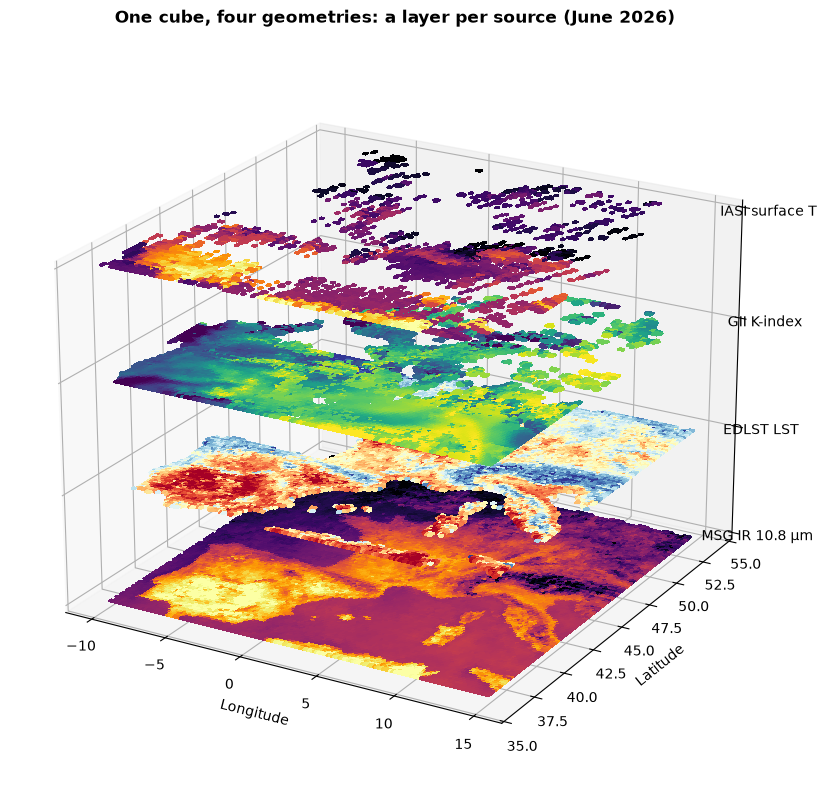

In [12]:
def pick(source, fragment):
    return next(v for v in cube.data_vars if source_of(v) == source and fragment in v)

resolved = [
    (pick("MSG", "IR_108"),            "MSG IR 10.8 µm",  "inferno",  True),
    (pick("EDLST", "LST"),             "EDLST LST",       "RdYlBu_r", False),
    (pick("GII", "k_index"),           "GII K-index",     "viridis",  False),
    (pick("IASI", "surface_temperature"), "IASI surface T", "inferno", True),
]

step = 3
lon2d, lat2d = np.meshgrid(cube["lon"].values[::step], cube["lat"].values[::step])

fig = plt.figure(figsize=(11, 10))
ax = fig.add_subplot(111, projection="3d")
for z, (name, label, cmap, to_c) in enumerate(resolved):
    data = cube[name].isel(time=0, drop=True).values[::step, ::step]
    if to_c:
        data = data - 273.15
    norm = mcolors.Normalize(vmin=np.nanpercentile(data, 2), vmax=np.nanpercentile(data, 98))
    colors = plt.get_cmap(cmap)(norm(data))
    colors[np.isnan(data)] = [0, 0, 0, 0]
    ax.plot_surface(lon2d, lat2d, np.full(lon2d.shape, float(z)), facecolors=colors,
                    rstride=1, cstride=1, shade=False, antialiased=False)

ax.set_zticks(range(len(resolved)))
ax.set_zticklabels([l for _, l, _, _ in resolved])
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("One cube, four geometries: a layer per source (June 2026)", fontweight="bold")
ax.view_init(elev=22, azim=-60)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "heterogeneous_cube_3d.png"), dpi=150, bbox_inches="tight")
plt.show()

### The four layers as maps

The same four fields drawn flat, side by side, so the coverage of each is legible on its own. The two imagers fill the frame; EDLST and GII show their clear-sky gaps; and the IASI panel shows only the diagonal ground tracks of a single day's overpasses, empty between passes and under cloud. Read on its own the IASI map looks sparse, which is precisely what a one-day sounder swath is; its value is not standalone coverage but the fourth, radically different geometry it contributes to the stack above.

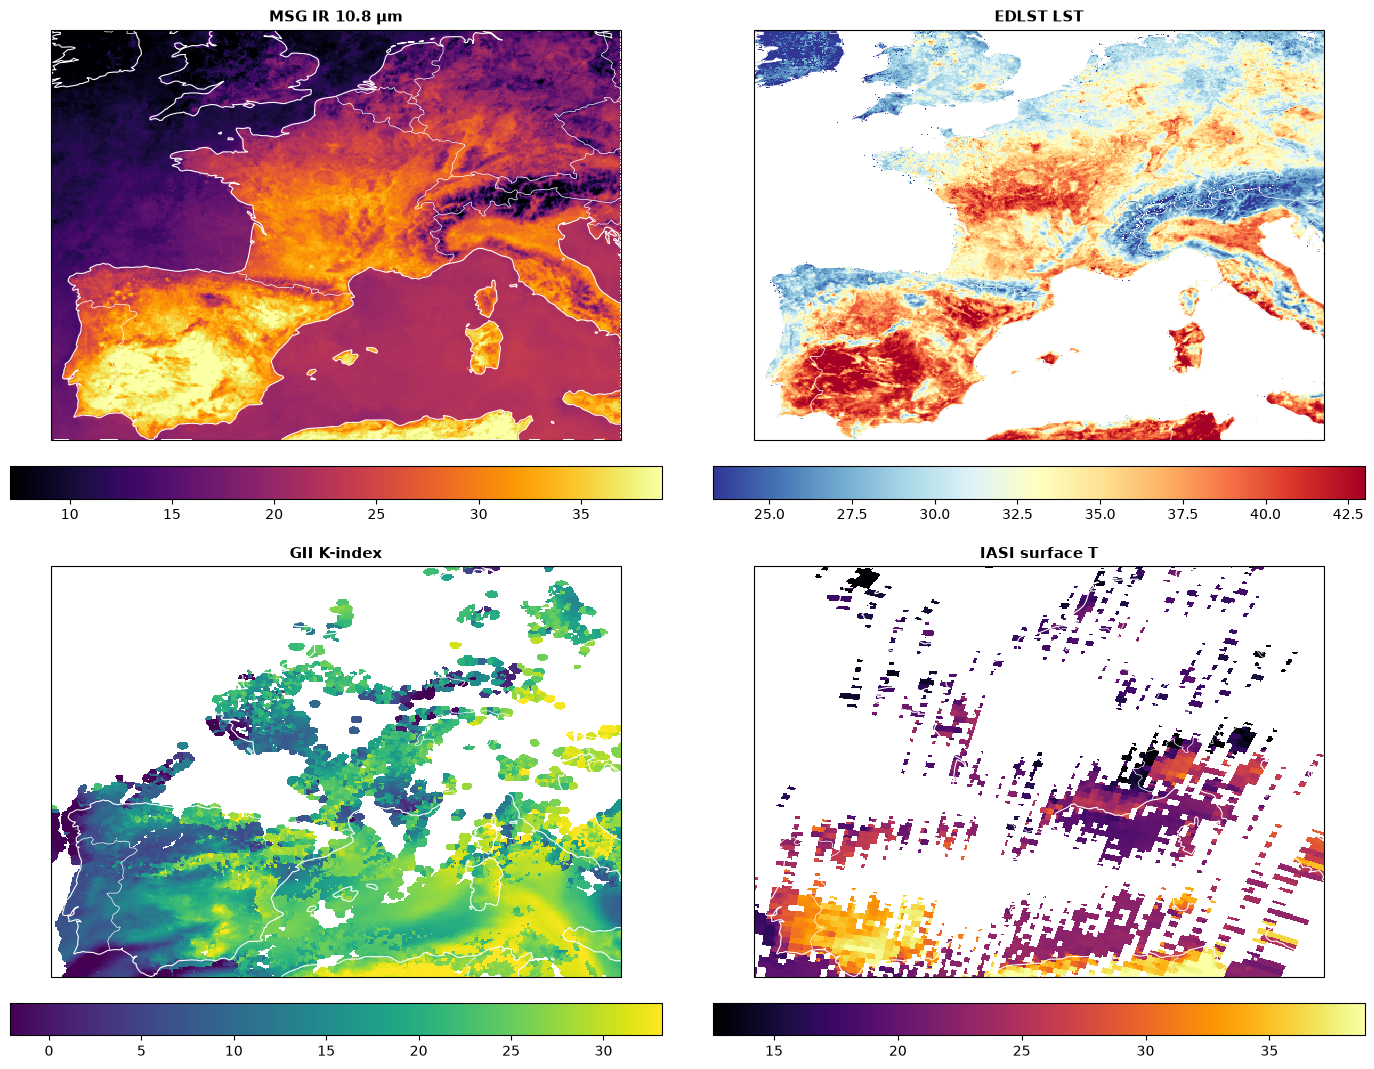

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11), subplot_kw={"projection": ccrs.PlateCarree()})
for ax, (name, label, cmap, to_c) in zip(axes.ravel(), resolved):
    data = cube[name].isel(time=0, drop=True)
    vals = data.values - 273.15 if to_c else data.values
    vmin, vmax = np.nanpercentile(vals, 2), np.nanpercentile(vals, 98)
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    im = ax.pcolormesh(data["lon"].values, data["lat"].values, vals, cmap=cmap,
                       vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree(), shading="auto")
    ax.coastlines(resolution="50m", linewidth=0.8, color="white")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="white")
    ax.set_title(label, fontsize=11, fontweight="bold")
    plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.85)
plt.tight_layout()
plt.show()

### Traceability: the cube's processing history

Every DEFAIR operation appends a line to the dataset's CF `history` attribute, recording when it ran, which plugin did it and with which parameters. Printed below for the aggregated cube, it documents the chain of the *base* source, MSG, end to end, including the final percentile aggregation with its `q`. The other three stacks each keep their own complete history in their own objects; those chains are not copied into the merged cube.

In [14]:
print(cube.attrs.get("history", "No history attribute found"))

2026-09-09T17:03:33.506176+00:00: Read operation [DEFAIR v0.4.0rc2:MSG15NativeReaderPlugin, channels=['IR_108', 'IR_120'], source='s3://defair-use-case/msg-eu-orig/MSG3-SEVI-MSG1...']
2026-09-09T17:03:39.496452+00:00: Transform operation [DEFAIR v0.4.0rc2:SpatialFilterPlugin, lat_min=36.0, lat_max=54.0, lon_min=-10.0, lon_max=15.0, polygon=None, drop=True, allow_partial=True, coordinate_group=None]
2026-09-09T17:05:52.312296+00:00: Transform operation [DEFAIR v0.4.0rc2:Reprojection, target=ReferenceGrid(crs='EPSG:4326', transform=(0.05, 0.0, -10.0, 0.0, -0.05, 54.0), width=500, height=360), resampling='bilinear', backend=None, resolution_unit='degrees']
2026-09-09T17:03:41.272800+00:00: Read operation [DEFAIR v0.4.0rc2:MetopEDLSTReaderPlugin, variables=None, source='s3://defair-use-case/edlst-eu-orig/S-LSA_-HDF5_...']
2026-09-09T17:03:53.787813+00:00: Transform operation [DEFAIR v0.4.0rc2:ContentFilterPlugin, include_vars=['LST'], exclude_vars=None, squeeze_dims=None]
2026-09-09T17:03:

## Conclusions

What this use case demonstrates about DEFAIR:

- **Four native geometries brought onto one grid.** A geostationary imager, a global sinusoidal product, the MTG grid and an orbital swath end up as co-registered layers of a single cube. The three gridded sources are reprojected and merged in one `AlignmentPlugin` call; the swath source, IASI, goes through the same plugin but by its swath-resampling path, which is heavier, so it is handled as a single-day reference layer rather than a full series. The user never selects a resampling method by hand: the plugin chooses it from each source's geometry.

- **Multi-file reading across formats.** Each source is opened with the reader named for its format, `msg15nat`, `metop_edlst`, `mtg_l2_gii`, `metop_iasisnd02`, in a wildcard call streamed from S3. For the three gridded sources a ten-day acquisition loop becomes one line each; IASI is read the same way but restricted to one day.

- **A pinned `ReferenceGrid` makes the pipeline deterministic.** Declaring the output grid explicitly guarantees pixel-identical results across runs and skips the framework's geometry probing.

- **Heterogeneous coverage, honestly represented.** The four sources cover the region very differently, from the near-complete geostationary imager to the sparse ground tracks of a one-day sounder swath, and the cube holds them side by side without hiding the gaps. The percentile reducer summarises each variable on the same footing and records the choice in the cube's metadata.

- **A design choice for portability.** Resampling ten days of IASI swaths is memory-heavy and needs a large session; reading a single representative day keeps the whole notebook within a standard pod. Where a fuller IASI layer is wanted, the swath resampling can instead be done once during ingestion, storing the gridded fields in the bucket so the notebook reads a light regular grid.

- **An all-EUMETSAT, single-bucket workflow.** The four sources sit under sibling prefixes in one bucket, streamed at read time with one set of credentials, and the cube is built without a single file touching local disk.

The cube produced here, seven variables from four instruments on one grid with a documented processing history, is exactly the analysis-ready input a downstream model or study expects. Building it, not modelling on it, was the point.